# 한국은행(KOSIS) 통계표 EDA & QC

**목적** — KOSIS Open API 중 **한국은행(기관코드 301) 소관 통계표** 전체를 수집·관찰하고,
EDA(탐색적 데이터 분석)와 QC(품질 점검)를 한 번에 수행한다.

**이 노트북이 답하는 것**
1. 한국은행 통계표는 몇 개이며 어떤 분류·주기·단위로 구성되는가 (EDA)
2. 실제 수치 데이터는 어떤 구조·형식으로 오며, 어디서 깨지는가 (QC)
3. 어떤 표를 함께 병합할 수 있고, 어떤 표가 수집이 어려운가 (병합 가능성 / QC)

**실행 환경** — **Colab 또는 로컬 Jupyter 모두 지원**.
- 인증키: Colab Secrets(`KOSIS_API_KEY`) → 환경변수 → **상위 폴더의 `.env`**(예: 프로젝트 루트) → 직접입력 순으로 자동 로드.
- 저장 위치: Colab이면 Google Drive, **로컬이면 프로젝트 루트의 `data/`**(자동 탐색).
- 필요 패키지: Colab은 자동 설치, 로컬은 없으면 설치 안내를 출력.

**산출물** — `data/catalog/`, `data/meta/`, `data/raw/`, `data/qc/qc_report.csv`

> ⚠️ 이 노트북의 모든 수치는 KOSIS Open API 조회 결과만 사용한다(모델 생성 금지 원칙).

## Part 0. 환경 설정

In [1]:
# 필요 패키지 확인 — Colab이면 자동 설치, 로컬이면 안내만
import sys, subprocess, importlib.util
def _pip(pkgs):
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
    except Exception as e:
        print("pip skip:", e)

_missing = [m for m in ("requests", "pandas", "numpy", "matplotlib")
            if importlib.util.find_spec(m) is None]
if _missing:
    if "google.colab" in sys.modules:
        _pip(_missing)
    else:
        print("누락 패키지:", _missing, "→ `pip install", " ".join(_missing), "` 후 커널 재시작")
else:
    print("패키지 확인 완료")

패키지 확인 완료


In [2]:
import os, re, sys, json, time, math, platform, threading
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

BASE_URL   = "https://kosis.kr"
LIST_URL   = f"{BASE_URL}/openapi/statisticsList.do"
DATA_URL   = f"{BASE_URL}/openapi/Param/statisticsParameterData.do"
META_URL   = f"{BASE_URL}/openapi/statisticsData.do"

ORG_ID = "301"          # 한국은행
VW_CD  = "MT_OTITLE"    # 국내통계 기관별

# ---- 수집 튜닝값 -----------------------------------------------------------
WORKERS      = 6        # 동시 수집 워커 수
RATE_PER_MIN = 180      # 분당 호출 한도(KOSIS 200/분에 여유). 토큰버킷으로 제한
MAX_RETRY    = 5
MAX_CELLS    = 40000    # KOSIS 요청당 셀 제한
NEWEST_CNT_FULL = "10000"   # 사실상 전체 시점
TABLE_LIMIT  = None     # 테스트 시 숫자 지정, 전체는 None
FORCE_REFRESH = False   # True면 캐시 무시하고 재수집
FLATTEN_ROW_CAP = 1_500_000  # QC 평탄화 메모리 가드(초과 시 샘플링)

# ---- 저장 위치 -----------------------------------------------------------
# Colab이면 Google Drive(세션 종료 후에도 재개 가능), 로컬이면 프로젝트 루트의 data/
USE_DRIVE = True

def _find_project_root(start=None):
    # .env / company / .git 이 있는 상위 폴더를 프로젝트 루트로 자동 탐색
    p = Path(start or Path.cwd()).resolve()
    for d in [p, *p.parents]:
        if (d / ".env").exists() or (d / "company").is_dir() or (d / ".git").exists():
            return d
    return p

PROJECT_ROOT = _find_project_root()

def _resolve_data_dir():
    if USE_DRIVE and "google.colab" in sys.modules:
        try:
            from google.colab import drive
            drive.mount("/content/drive")
            d = Path("/content/drive/MyDrive/StatBridge/data")
            d.mkdir(parents=True, exist_ok=True)
            print("데이터 저장 위치: Google Drive", d)
            return d
        except Exception as e:
            print("Drive 마운트 실패 → 로컬 data/ 사용:", e)
    d = PROJECT_ROOT / "data"
    print("데이터 저장 위치: 로컬", d)
    return d

DATA_DIR = _resolve_data_dir()
CATALOG_DIR, META_DIR, RAW_DIR, QC_DIR = (
    DATA_DIR / "catalog", DATA_DIR / "meta", DATA_DIR / "raw", DATA_DIR / "qc")
for _d in (CATALOG_DIR, META_DIR, RAW_DIR, QC_DIR):
    _d.mkdir(parents=True, exist_ok=True)

print("python", sys.version.split()[0], "| cwd", Path.cwd())
print("dirs ready:", DATA_DIR.resolve())

데이터 저장 위치: 로컬 C:\Users\cheon\orca\projects\StatBridge-EX-1\data
python 3.13.9 | cwd C:\Users\cheon\orca\projects\StatBridge-EX-1\notebooks
dirs ready: C:\Users\cheon\orca\projects\StatBridge-EX-1\data


In [3]:
# 한글 폰트 (Colab은 나눔폰트 설치, 그 외는 시스템 폰트 탐색)
def _ensure_korean_font():
    import matplotlib.font_manager as fm
    if "google.colab" in sys.modules:
        try:
            import subprocess
            subprocess.run("apt-get install -y fonts-nanum > /dev/null 2>&1", shell=True)
        except Exception:
            pass
        p = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if Path(p).exists():
            fm.fontManager.addfont(p)
            plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()
            plt.rcParams["axes.unicode_minus"] = False
            return plt.rcParams["font.family"]
    if platform.system() == "Windows":
        p = r"C:/Windows/Fonts/malgun.ttf"
        if Path(p).exists():
            fm.fontManager.addfont(p)
            plt.rcParams["font.family"] = fm.FontProperties(fname=p).get_name()
            return plt.rcParams["font.family"]
    for cand in ["NanumGothic", "Malgun Gothic", "AppleGothic", "Noto Sans CJK KR", "DejaVu Sans"]:
        if any(cand.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = cand
            return cand
    return None
FONT = _ensure_korean_font()
plt.rcParams["axes.unicode_minus"] = False
print("font:", FONT)

font: ['Malgun Gothic']


In [4]:
# 인증키 로딩: Colab Secrets → 환경변수 → .env → 직접입력
def load_kosis_key():
    if os.environ.get("KOSIS_API_KEY"):
        return os.environ["KOSIS_API_KEY"], "env"
    try:  # Colab
        from google.colab import userdata
        k = userdata.get("KOSIS_API_KEY")
        if k:
            return k, "colab.userdata"
    except Exception:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()
        if os.environ.get("KOSIS_API_KEY"):
            return os.environ["KOSIS_API_KEY"], "dotenv"
    except Exception:
        pass
    p = PROJECT_ROOT / ".env"
    if p.exists():
        for line in p.read_text(encoding="utf-8").splitlines():
            if line.strip().startswith("KOSIS_API_KEY="):
                v = line.split("=", 1)[1].strip().strip('"').strip("'")
                if v:
                    return v, ".env"
    from getpass import getpass
    return getpass("KOSIS_API_KEY: "), "getpass"

API_KEY, KEY_SRC = load_kosis_key()
print("key loaded:", bool(API_KEY), "| len", len(API_KEY), "| source", KEY_SRC)

key loaded: True | len 44 | source dotenv


In [5]:
# 스레드 안전 토큰버킷 레이트리미터 + 스레드별 Session + 공통 호출 헬퍼
# (HTTP 200이어도 본문 err 키를 반드시 검사)
class RateLimiter:
    def __init__(self, per_min, burst=None):
        self.rate = per_min / 60.0            # 초당 토큰
        self.capacity = burst or max(1, WORKERS)
        self.tokens = min(1.0, self.capacity)
        self.last = time.time()
        self.lock = threading.Lock()
    def acquire(self):
        while True:
            with self.lock:
                now = time.time()
                self.tokens = min(self.capacity, self.tokens + (now - self.last) * self.rate)
                self.last = now
                if self.tokens >= 1:
                    self.tokens -= 1
                    return
                need = (1 - self.tokens) / self.rate
            time.sleep(min(max(need, 0.01), 1.0))

_limiter = RateLimiter(RATE_PER_MIN)

_tls = threading.local()
def get_session():
    s = getattr(_tls, "session", None)
    if s is None:
        s = requests.Session()
        s.headers.update({"User-Agent": "kosis-eda/1.0"})
        _tls.session = s
    return s

CALLS = {"count": 0, "err40": 0, "other_err": 0}
_calls_lock = threading.Lock()

ERR_MSG = {
    "11": "유효하지 않은 인증키", "20": "필수요청변수 누락(주로 objL 개수 불일치)",
    "21": "잘못된 요청 변수", "30": "데이터 없음", "31": "40,000셀 초과",
    "40": "분당 호출 200건 초과(레이트리밋)",
}

def _parse_json(text):
    # KOSIS가 드물게 잘못된 역슬래시 이스케이프를 반환한다 (예: "Up to @ million")
    try:
        return json.loads(text)
    except Exception:
        try:
            return json.loads(re.sub(r'\\(?![\\"/bfnrtu])', r'\\\\', text))
        except Exception:
            return None

def kosis_get(url, **params):
    params.setdefault("apiKey", API_KEY)
    last = None
    for attempt in range(MAX_RETRY):
        _limiter.acquire()
        with _calls_lock:
            CALLS["count"] += 1
        try:
            r = get_session().get(url, params=params, timeout=60)
        except Exception as e:
            last = {"err": "EXC", "errMsg": str(e)}
            time.sleep(1.5 * (attempt + 1)); continue
        data = _parse_json(r.text)
        if data is None:
            last = {"err": "PARSE", "errMsg": r.text[:200]}
            time.sleep(1.0); continue
        if isinstance(data, dict) and data.get("err"):
            if str(data["err"]) == "40":          # 레이트리밋 → 대기 후 재시도
                with _calls_lock:
                    CALLS["err40"] += 1
                time.sleep(20); last = data; continue
            with _calls_lock:
                CALLS["other_err"] += 1
            return data
        return data
    return last if isinstance(last, dict) else {"err": "EXHAUSTED", "errMsg": str(last)}

def as_list(d):
    # .json() 결과가 dict(err)면 None, list면 그대로
    return d if isinstance(d, list) else None

def err_code(d):
    return str(d.get("err")) if isinstance(d, dict) else None

In [6]:
# QC-0. 연결 / 인증키 유효성 테스트
_t = kosis_get(LIST_URL, method="getList", vwCd=VW_CD, parentListId="301",
               format="json", jsonVD="Y")
if isinstance(_t, list):
    print("OK 연결 성공 | 한국은행 하위 항목", len(_t), "건")
    print("샘플:", [x.get("LIST_NM") for x in _t[:5]])
else:
    print("연결 실패 →", _t, "|", ERR_MSG.get(_t.get("err"), "") if isinstance(_t, dict) else "")

OK 연결 성공 | 한국은행 하위 항목 17 건
샘플: ['경제심리지수', '국민계정', '국제수지통계', '국제투자대조표(IIP)', '금융기관대출행태조사']


## Part 1. 한국은행 통계표 카탈로그 수집

한국은행(301) 아래에는 **카테고리(LIST_ID) → 통계표(TBL_ID)** 트리가 있다.
`parentListId`로 재귀 탐색해 한국은행 소관 표 전체를 수집한다.

> 참고(문서 04 정정): 통계목록 파라미터는 `parentId`가 아니라 **`parentListId`**이며,
> 최상위(기관별) 조회는 생략, 하위는 직전 응답의 `LIST_ID`를 넘긴다.

In [7]:
def list_children(parent_id):
    d = kosis_get(LIST_URL, method="getList", vwCd=VW_CD,
                  parentListId=parent_id, format="json", jsonVD="Y")
    return as_list(d) or []

def build_catalog(root=ORG_ID):
    tables, visited = {}, set()
    def rec(node_id, path):
        if node_id in visited:
            return
        visited.add(node_id)
        for x in list_children(node_id):
            if not isinstance(x, dict):
                continue
            if x.get("TBL_ID"):
                tid = x["TBL_ID"]
                if tid not in tables:
                    tables[tid] = {
                        "tbl_id": tid, "tbl_nm": x.get("TBL_NM"),
                        "stat_id": x.get("STAT_ID"), "org_id": x.get("ORG_ID"),
                        "send_de": x.get("SEND_DE"), "rec_tbl_se": x.get("REC_TBL_SE"),
                        "category": " > ".join(path),
                    }
            elif x.get("LIST_ID"):
                rec(x["LIST_ID"], path + [x.get("LIST_NM")])
    rec(root, [])
    cols = ["tbl_id", "tbl_nm", "stat_id", "org_id", "send_de", "rec_tbl_se", "category"]
    return pd.DataFrame(list(tables.values()), columns=cols)

CATALOG_JSON = CATALOG_DIR / "kosis_hankuk_catalog.json"
CATALOG_CSV  = CATALOG_DIR / "kosis_hankuk_catalog.csv"

def _load_cache_json(path):
    # 손상/빈 캐시 안전 로드
    if path.exists() and path.stat().st_size > 0:
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception as e:
            print("캐시 무시(손상):", path.name, e)
    return None

_cached = None if FORCE_REFRESH else _load_cache_json(CATALOG_JSON)
if _cached is not None:
    catalog = pd.DataFrame(_cached)
    print("카탈로그 캐시 로드:", len(catalog), "표  (FORCE_REFRESH=True 로 재수집)")
else:
    catalog = build_catalog()
    if catalog.empty:
        diag = kosis_get(LIST_URL, method="getList", vwCd=VW_CD,
                         parentListId=ORG_ID, format="json", jsonVD="Y")
        print("⚠️ 카탈로그 0건 — 진단 응답:", diag)
        print("   인증키·네트워크·레이트리밋 확인 후 다시 실행하세요.")
    else:
        catalog.to_json(CATALOG_JSON, orient="records", force_ascii=False)
        catalog.to_csv(CATALOG_CSV, index=False, encoding="utf-8-sig")
        print("카탈로그 수집 완료:", len(catalog), "표 →", CATALOG_JSON)

print("총 API 호출:", CALLS["count"])
catalog.head()

카탈로그 수집 완료: 349 표 → C:\Users\cheon\orca\projects\StatBridge-EX-1\data\catalog\kosis_hankuk_catalog.json
총 API 호출: 135


,tbl_id,tbl_nm,stat_id,org_id,send_de,rec_tbl_se,category
0,DT_513Y001,경제심리지수,2012013,301,2026-09-30,N,경제심리지수
1,DT_200Y101,주요지표(연간지표),1976017,301,2026-09-30,N,국민계정 > 국민계정(2020년기준) > 주요지표
2,DT_200Y102,주요지표(분기지표),1976017,301,2026-09-30,N,국민계정 > 국민계정(2020년기준) > 주요지표
3,DT_200Y103,"경제활동별 GDP 및 GNI(계절조정, 명목, 분기)",1976017,301,2026-09-30,N,"국민계정 > 국민계정(2020년기준) > 경제활동별, 지출항목별, 부가가치항목별 규모"
4,DT_200Y104,"경제활동별 GDP 및 GNI(계절조정, 실질, 분기)",1976017,301,2026-09-30,N,"국민계정 > 국민계정(2020년기준) > 경제활동별, 지출항목별, 부가가치항목별 규모"


In [8]:
print("통계표 수:", len(catalog))
print("중복 tbl_id:", catalog["tbl_id"].duplicated().sum())
print("최상위 카테고리 수:", catalog["category"].str.split(" > ").str[0].nunique())
cat_summary = (catalog.assign(top=catalog["category"].str.split(" > ").str[0])
                      .groupby("top").size().sort_values(ascending=False))
cat_summary

통계표 수: 349
중복 tbl_id: 0
최상위 카테고리 수: 14


top
통화금융통계               117
기업경영분석                78
국민계정                  60
국제수지통계                18
기업경기조사                15
지급결제통계                15
자금순환표                 14
수출입물가조사(2020=100)     12
생산자물가조사(2020=100)      6
소비자동향조사                4
국제투자대조표(IIP)           3
금융기관대출행태조사             3
대외채무및대외채권              3
경제심리지수                 1
dtype: int64

In [9]:
# QC-1. 카탈로그 무결성
qc_catalog = pd.DataFrame({
    "check": ["tbl_id 결측", "tbl_id 중복", "tbl_nm 결측", "send_de 결측", "표 0건"],
    "count": [catalog["tbl_id"].isna().sum(),
              catalog["tbl_id"].duplicated().sum(),
              catalog["tbl_nm"].isna().sum(),
              catalog["send_de"].isna().sum(),
              int(len(catalog) == 0)],
})
qc_catalog

,check,count
0,tbl_id 결측,0
1,tbl_id 중복,0
2,tbl_nm 결측,0
3,send_de 결측,0
4,표 0건,0


## Part 2. 메타정보 수집 & EDA

표마다 `getMeta`로 명칭·기관·단위·수록주기·출처·분류/항목을 수집한다.
**분류 차원 수(`n_class_dims`)는 Part 3에서 `objL` 개수를 정하는 핵심 값**이다.

> 메타 수집은 표 단위로 **병렬화**되어 있다(워커 수 = `WORKERS`).

In [10]:
def get_meta(tbl, mtype, **extra):
    p = dict(method="getMeta", type=mtype, orgId=ORG_ID, tblId=tbl,
             format="json", jsonVD="Y")
    p.update(extra)
    return kosis_get(META_URL, **p)

def summarize_meta(tbl):
    out = {"tbl_id": tbl}
    t = get_meta(tbl, "TBL")
    if as_list(t):
        out["tbl_nm"] = t[0].get("TBL_NM"); out["tbl_nm_eng"] = t[0].get("TBL_NM_ENG")
    o = get_meta(tbl, "ORG")
    if as_list(o):
        out["org_nm"] = o[0].get("ORG_NM")
    u = get_meta(tbl, "UNIT")
    if as_list(u):
        out["units"] = [r.get("UNIT_NM") for r in u if r.get("UNIT_NM")]
    p = get_meta(tbl, "PRD", detail="Y")
    if as_list(p):
        byse, flat, cur = {}, [], None
        for r in p:
            se, de = r.get("PRD_SE"), r.get("PRD_DE")
            if se:                       # PRD_SE는 별도 행에 한 번 오고, 이후 행은 PRD_DE만
                cur = se
            if de and cur:
                byse.setdefault(cur, []).append(de); flat.append(de)
        out["prd_ses"] = sorted(byse.keys())
        out["periods_by_se"] = byse
        out["periods"] = flat
        out["n_periods"] = len(flat)
    s = get_meta(tbl, "SOURCE")
    if as_list(s):
        out["source"] = {k: s[0].get(k) for k in ("JOSA_NM", "DEPT_NM", "STAT_ID")}
    itm = get_meta(tbl, "ITM")
    if as_list(itm):
        dims = {}
        for r in itm:
            oid = r.get("OBJ_ID")
            if not oid: continue
            dims.setdefault(oid, {"obj_nm": r.get("OBJ_NM"), "n": 0})
            dims[oid]["n"] += 1
        out["dims"] = [{"obj_id": k, "obj_nm": v["obj_nm"], "n": v["n"]}
                       for k, v in dims.items()]
        out["n_class_dims"] = len([k for k in dims if k != "ITEM"])
        out["n_items"] = dims.get("ITEM", {}).get("n", 0)
    return out

def _collect_one_meta(tbl):
    fp = META_DIR / f"{tbl}.json"
    m = None if FORCE_REFRESH else _load_cache_json(fp)
    if m is None:
        m = summarize_meta(tbl)
        if m.get("tbl_nm") or m.get("dims") or m.get("periods"):
            fp.write_text(json.dumps(m, ensure_ascii=False, indent=1), encoding="utf-8")
    return m

tids = list(catalog["tbl_id"])
if TABLE_LIMIT:
    tids = tids[:TABLE_LIMIT]
meta_list = [None] * len(tids)
t0 = time.time(); done = 0
with ThreadPoolExecutor(WORKERS) as ex:
    futs = {ex.submit(_collect_one_meta, tbl): i for i, tbl in enumerate(tids)}
    for f in as_completed(futs):
        meta_list[futs[f]] = f.result()
        done += 1
        if done % 25 == 0 or done == len(tids):
            el = time.time() - t0
            eta = el / done * (len(tids) - done)
            print(f"{done}/{len(tids)}  ({el:.0f}s, {el/done:.2f}s/표, ETA {eta/60:.1f}m, calls={CALLS['count']})")

meta = pd.json_normalize(meta_list, max_level=0)
meta.to_json(META_DIR / "meta_all.json", orient="records", force_ascii=False)
print("메타 수집:", len(meta_list), "표 |", f"{time.time()-t0:.0f}s")
meta.head()

25/349  (56s, 2.25s/표, ETA 12.2m, calls=304)
50/349  (103s, 2.06s/표, ETA 10.3m, calls=445)
75/349  (153s, 2.04s/표, ETA 9.3m, calls=595)
100/349  (203s, 2.03s/표, ETA 8.4m, calls=744)
125/349  (253s, 2.02s/표, ETA 7.5m, calls=893)
150/349  (302s, 2.01s/표, ETA 6.7m, calls=1041)
175/349  (353s, 2.02s/표, ETA 5.9m, calls=1194)
200/349  (403s, 2.01s/표, ETA 5.0m, calls=1344)
225/349  (452s, 2.01s/표, ETA 4.2m, calls=1492)
250/349  (506s, 2.03s/표, ETA 3.3m, calls=1654)
275/349  (554s, 2.01s/표, ETA 2.5m, calls=1797)
300/349  (606s, 2.02s/표, ETA 1.6m, calls=1952)
325/349  (654s, 2.01s/표, ETA 0.8m, calls=2098)
349/349  (698s, 2.00s/표, ETA 0.0m, calls=2229)
메타 수집: 349 표 | 698s


,tbl_id,tbl_nm,tbl_nm_eng,org_nm,prd_ses,periods_by_se,periods,n_periods,source,dims,n_class_dims,n_items,units
0,DT_513Y001,경제심리지수,Economic Sentiment Index,한국은행,[월],"{'월': ['2003.01', '2003.02', '2003.03', '2003....","[2003.01, 2003.02, 2003.03, 2003.04, 2003.05, ...",285,"{'JOSA_NM': '「경제심리지수」', 'DEPT_NM': '한국은행 경제통계...","[{'obj_id': 'ITEM', 'obj_nm': '항목', 'n': 1}, {...",1,1,NaN
1,DT_200Y101,주요지표(연간지표),Main Annual Indicators (reference year 2020),한국은행,[년],"{'년': ['1953', '1954', '1955', '1956', '1957',...","[1953, 1954, 1955, 1956, 1957, 1958, 1959, 196...",73,"{'JOSA_NM': '「국민계정」', 'DEPT_NM': '한국은행 경제통계2국 ...","[{'obj_id': 'ITEM', 'obj_nm': '항목', 'n': 1}, {...",1,1,NaN
2,DT_200Y102,주요지표(분기지표),Main Quarterly Indicators (reference year 2020),한국은행,[분기],"{'분기': ['1960 1/4', '1960 2/4', '1960 3/4', '1...","[1960 1/4, 1960 2/4, 1960 3/4, 1960 4/4, 1961 ...",266,"{'JOSA_NM': '「국민계정」', 'DEPT_NM': '한국은행 경제통계2국 ...","[{'obj_id': 'ITEM', 'obj_nm': '항목', 'n': 1}, {...",1,1,NaN
3,DT_200Y103,"경제활동별 GDP 및 GNI(계절조정, 명목, 분기)",GDP and GNI by Economic Activities (seasonally...,한국은행,[분기],"{'분기': ['1960 1/4', '1960 2/4', '1960 3/4', '1...","[1960 1/4, 1960 2/4, 1960 3/4, 1960 4/4, 1961 ...",266,"{'JOSA_NM': '「국민계정」', 'DEPT_NM': '한국은행 경제통계2국 ...","[{'obj_id': 'ITEM', 'obj_nm': '항목', 'n': 1}, {...",1,1,[십억원]
4,DT_200Y104,"경제활동별 GDP 및 GNI(계절조정, 실질, 분기)",GDP and GNI by Economic Activities (seasonally...,한국은행,[분기],"{'분기': ['1960 1/4', '1960 2/4', '1960 3/4', '1...","[1960 1/4, 1960 2/4, 1960 3/4, 1960 4/4, 1961 ...",266,"{'JOSA_NM': '「국민계정」', 'DEPT_NM': '한국은행 경제통계2국 ...","[{'obj_id': 'ITEM', 'obj_nm': '항목', 'n': 1}, {...",1,1,[십억원]


In [11]:
# 메타를 분석용 평탄 DataFrame으로
def _units(m): return m.get("units", []) or []
def _prds(m):  return m.get("prd_ses", []) or []

meta_df = pd.DataFrame([{
    "tbl_id": m.get("tbl_id"),
    "tbl_nm": m.get("tbl_nm"),
    "org_nm": m.get("org_nm"),
    "n_class_dims": m.get("n_class_dims") if m.get("n_class_dims") is not None else np.nan,
    "n_items": m.get("n_items") if m.get("n_items") is not None else np.nan,
    "units": _units(m),
    "unit_first": _units(m)[0] if _units(m) else None,
    "prd_ses": _prds(m),
    "prd_main": _prds(m)[0] if _prds(m) else None,
    "n_periods": m.get("n_periods"),
    "source": (m.get("source") or {}).get("JOSA_NM"),
    "dept": (m.get("source") or {}).get("DEPT_NM"),
} for m in meta_list])
meta_df = meta_df.merge(catalog[["tbl_id", "category", "send_de"]], on="tbl_id", how="left")
meta_df["top"] = meta_df["category"].str.split(" > ").str[0]
print(meta_df.shape)
meta_df.head()

(349, 15)


,tbl_id,tbl_nm,org_nm,n_class_dims,n_items,units,unit_first,prd_ses,prd_main,n_periods,source,dept,category,send_de,top
0,DT_513Y001,경제심리지수,한국은행,1,1,[],None,[월],월,285,「경제심리지수」,한국은행 경제통계1국 경제심리조사팀,경제심리지수,2026-09-30,경제심리지수
1,DT_200Y101,주요지표(연간지표),한국은행,1,1,[],None,[년],년,73,「국민계정」,한국은행 경제통계2국 국민소득총괄팀,국민계정 > 국민계정(2020년기준) > 주요지표,2026-09-30,국민계정
2,DT_200Y102,주요지표(분기지표),한국은행,1,1,[],None,[분기],분기,266,「국민계정」,한국은행 경제통계2국 국민소득총괄팀,국민계정 > 국민계정(2020년기준) > 주요지표,2026-09-30,국민계정
3,DT_200Y103,"경제활동별 GDP 및 GNI(계절조정, 명목, 분기)",한국은행,1,1,[십억원],십억원,[분기],분기,266,「국민계정」,한국은행 경제통계2국 국민소득총괄팀,"국민계정 > 국민계정(2020년기준) > 경제활동별, 지출항목별, 부가가치항목별 규모",2026-09-30,국민계정
4,DT_200Y104,"경제활동별 GDP 및 GNI(계절조정, 실질, 분기)",한국은행,1,1,[십억원],십억원,[분기],분기,266,「국민계정」,한국은행 경제통계2국 국민소득총괄팀,"국민계정 > 국민계정(2020년기준) > 경제활동별, 지출항목별, 부가가치항목별 규모",2026-09-30,국민계정


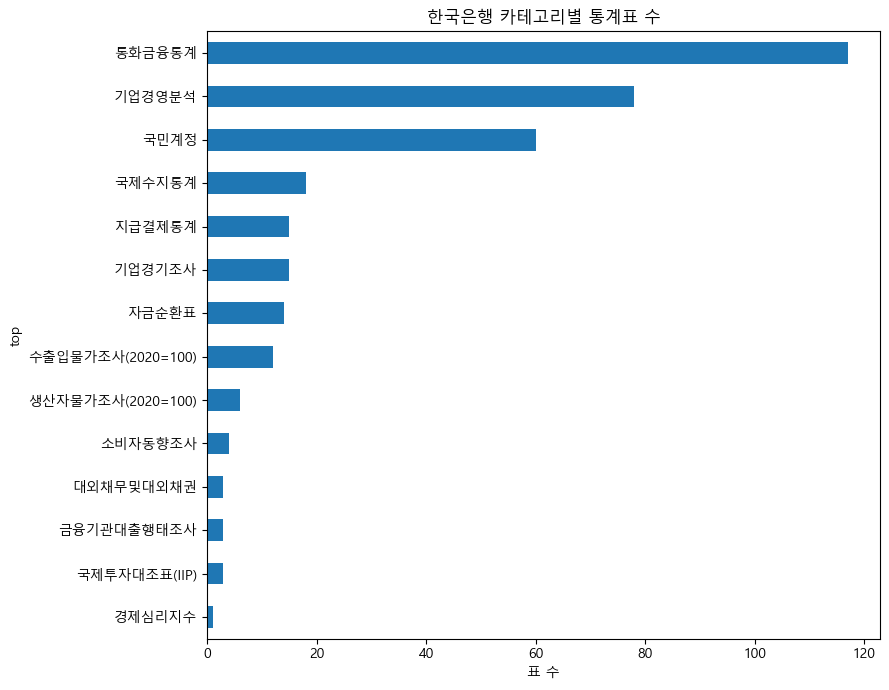

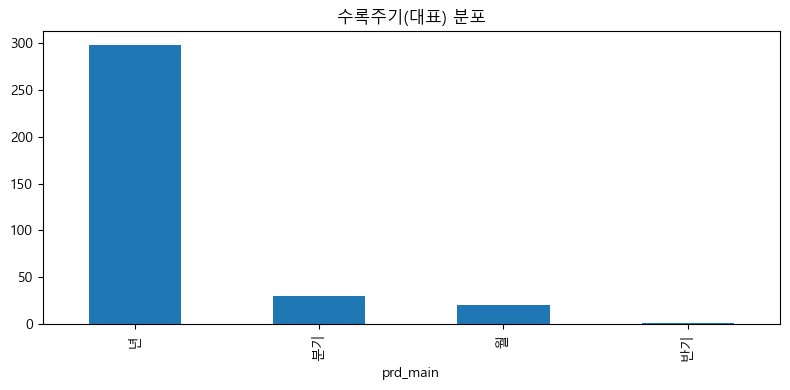

In [12]:
# EDA-1. 카테고리별 표 수
ax = cat_summary.sort_values().plot(kind="barh", figsize=(9, 7), title="한국은행 카테고리별 통계표 수")
ax.set_xlabel("표 수")
plt.tight_layout(); plt.show()

# EDA-2. 수록주기 분포 (대표 주기 기준)
meta_df["prd_main"].fillna("(미상)").value_counts().plot(
    kind="bar", figsize=(8, 4), title="수록주기(대표) 분포")
plt.tight_layout(); plt.show()

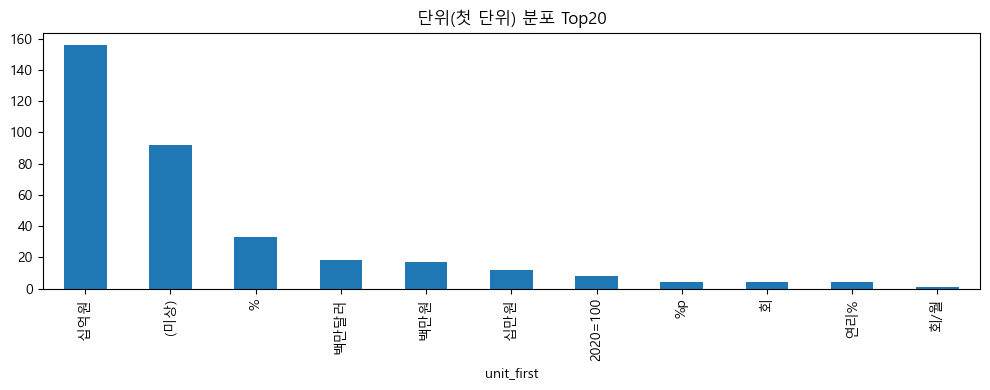

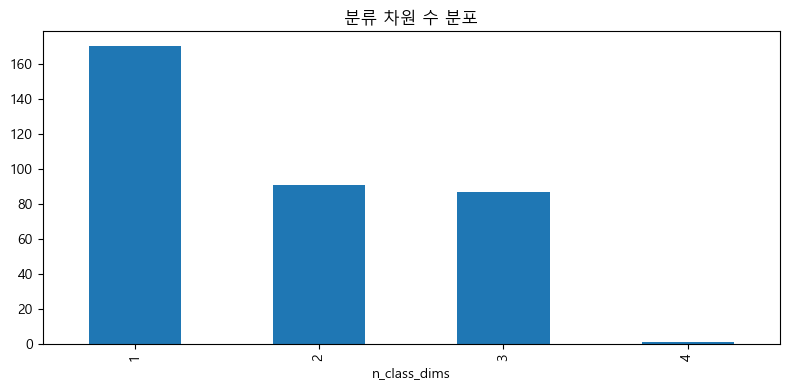

n_class_dims
1    170
2     91
3     87
4      1
Name: count, dtype: int64


In [13]:
# EDA-3. 단위 분포 (첫 단위 기준)
meta_df["unit_first"].fillna("(미상)").value_counts().head(20).plot(
    kind="bar", figsize=(10, 4), title="단위(첫 단위) 분포 Top20")
plt.tight_layout(); plt.show()

# EDA-4. 분류 차원 수 분포  ← Part 3 objL 개수와 직결
meta_df["n_class_dims"].value_counts(dropna=False).sort_index().plot(
    kind="bar", figsize=(8, 4), title="분류 차원 수 분포")
plt.tight_layout(); plt.show()
print(meta_df["n_class_dims"].value_counts(dropna=False).sort_index())

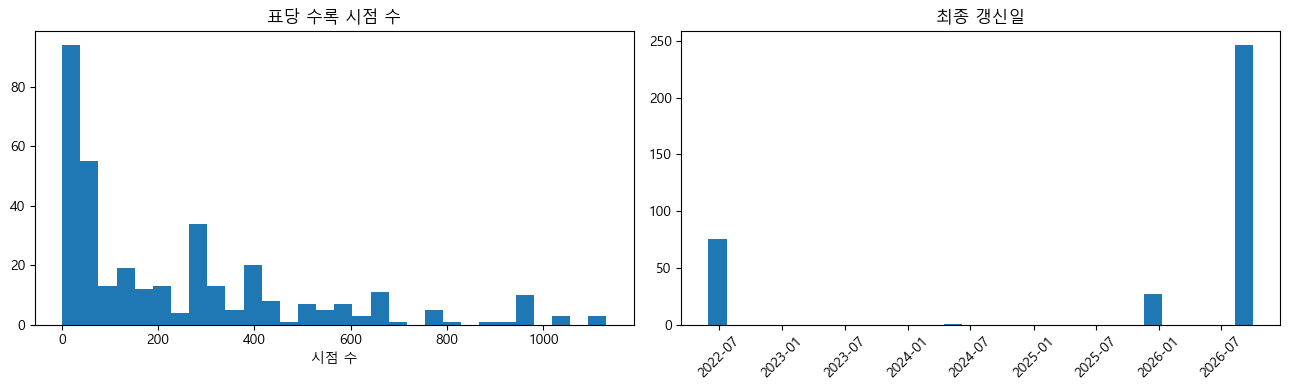

갱신일 최소/최대: 2022-05-31 00:00:00 ~ 2026-10-01 00:00:00


In [14]:
# EDA-5. 수록기간 길이 / 최신 갱신일
meta_df["n_periods"] = pd.to_numeric(meta_df["n_periods"], errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(meta_df["n_periods"].dropna(), bins=30)
axes[0].set_title("표당 수록 시점 수"); axes[0].set_xlabel("시점 수")
meta_df["send_de"] = pd.to_datetime(meta_df["send_de"], errors="coerce")
axes[1].hist(meta_df["send_de"].dropna(), bins=30)
axes[1].set_title("최종 갱신일"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
print("갱신일 최소/최대:", meta_df["send_de"].min(), "~", meta_df["send_de"].max())

In [15]:
# EDA-6. 표 제목 키워드 빈도 (검색기 씨앗: 사용자 표현 ↔ 통계표 명칭)
from collections import Counter
STOP = set("및 의 등 별 추이 동향 지수 통계 조사 현황".split())
tokens = Counter()
for nm in meta_df["tbl_nm"].dropna():
    for w in re.findall(r"[가-힣A-Za-z]{2,}", str(nm)):
        if w not in STOP:
            tokens[w] += 1
print("상위 키워드:", tokens.most_common(30))

상위 키워드: [('말잔', 50), ('분기', 42), ('원계열', 41), ('연간', 40), ('명목', 38), ('구성내역', 38), ('표본조사', 36), ('지역별', 27), ('상품별', 26), ('지표', 25), ('평잔', 25), ('예금은행', 25), ('계절조정계열', 22), ('실질', 21), ('계절조정', 18), ('경제활동별', 13), ('자산', 12), ('자본', 12), ('최종소비지출', 11), ('한국표준산업분류', 11), ('중소기업기본법', 10), ('조세특례제한법', 10), ('산업별대출금', 10), ('신규취급액', 10), ('부가가치', 9), ('비은행금융기관', 9), ('기준', 9), ('가계의', 8), ('기업경기실사지수', 8), ('재무상태표', 8)]


## Part 3. 실제 수치 데이터 수집 (전체 시점 · 동시 수집)

**핵심 규칙(검증 완료)**
- `itmId=ALL` (모든 항목)
- **`objL` 파라미터 개수는 분류 차원 수와 정확히 일치**해야 한다.
  (적으면 `err20`, 많으면 `err21`) → 그래서 `n_class_dims`가 필요하다.
- `newEstPrdCnt=10000` 이면 사실상 전체 시점이 온다.
- 결과가 40,000셀을 넘으면 `err31` → **차원 크기로 윈도우를 미리 계산**해 청킹한다.
- 호출은 분당 200회 제한 → 토큰버킷(180/분)으로 제한하고, 워커 6개로 동시 수집.
- 표별 JSON 캐시로 **중단 후 재개** 가능(Colab은 Drive에 저장).

> `ponytail:` 1개 시점의 시리즈 수가 4만을 넘는 표는 `UNSAMPLED`로 기록한다.
> 분류값 단위 청킹은 후속 주차에서 필요 시 추가.

In [16]:
PRD_CODE = {"년": "Y", "분기": "Q", "월": "M", "일": "D",
            "반기": "H", "부정기": "IR", "순기": "Y", "격월": "M"}

def period_key(s):
    if s is None: return None
    s = str(s).strip()
    try:
        if "/" in s:                       # "1960 1/4"
            y = s.split()[0]; q = s.split()[1].split("/")[0]
            return int(y) * 100 + int(q)
        if "." in s:                       # "2003.01" / "2003.01.01"
            p = s.split(".")
            if len(p) == 2: return int(p[0]) * 100 + int(p[1])
            if len(p) == 3: return int(p[0]) * 10000 + int(p[1]) * 100 + int(p[2])
        if "-" in s:
            p = s.split("-")
            if len(p) == 2: return int(p[0]) * 100 + int(p[1])
            if len(p) == 3: return int(p[0]) * 10000 + int(p[1]) * 100 + int(p[2])
        return int(s)
    except Exception:
        return None

def fmt_key(k, ps):
    return {"Y": f"{k:04d}", "M": f"{k:06d}", "Q": f"{k:06d}",
            "H": f"{k:06d}", "D": f"{k:08d}"}.get(ps, str(k))

def table_series_count(meta_rec):
    n = 1
    for d in (meta_rec.get("dims") or []):
        n *= max(1, int(d.get("n", 1)))
    return n

In [17]:
def fetch_table(tbl, meta_rec):
    n_dims = int(meta_rec.get("n_class_dims") or 0)
    prd_ses = meta_rec.get("prd_ses") or []
    by_se = meta_rec.get("periods_by_se") or {}
    series = table_series_count(meta_rec)
    rows, statuses, notes = [], [], []

    for pse in prd_ses:
        ps = PRD_CODE.get(pse)
        if ps is None:
            notes.append("skip " + str(pse)); continue
        base = dict(method="getList", orgId=ORG_ID, tblId=tbl,
                    itmId="ALL", prdSe=ps, format="json", jsonVD="Y")
        for i in range(1, n_dims + 1):
            base[f"objL{i}"] = "ALL"

        plist = by_se.get(pse, [])
        nper = len(plist)
        est_cells = series * nper if nper else None

        # (1) 한 번에 받을 수 있으면 단일 호출
        if est_cells is None or est_cells <= MAX_CELLS:
            d = kosis_get(DATA_URL, **base, newEstPrdCnt=NEWEST_CNT_FULL)
            if isinstance(d, list):
                rows.extend(d); statuses.append("FULL"); continue
            code_ = err_code(d)
            if code_ == "30":
                statuses.append("NODATA"); notes.append("해당 주기 데이터 없음"); continue
            if code_ != "31":
                statuses.append("ERR" + str(code_))
                notes.append(str(d.get("errMsg"))[:60] if isinstance(d, dict) else "")
                continue
            # 예상과 달리 초과 → 청킹으로

        # (2) 1개 시점도 4만 초과 → 수집 불가
        if series > MAX_CELLS:
            statuses.append("UNSAMPLED")
            notes.append(f"1개 시점 {series}시리즈 > {MAX_CELLS}")
            continue

        # (3) 차원 크기로 윈도우를 미리 계산해 청킹
        window = max(1, MAX_CELLS // max(1, series))
        keys = sorted({k for k in (period_key(x) for x in plist) if k is not None})
        if not keys:
            for n in (1000, 200, 50, 10, 1):
                dd = kosis_get(DATA_URL, **base, newEstPrdCnt=str(n))
                if isinstance(dd, list) and dd:
                    rows.extend(dd); statuses.append(f"PARTIAL(newest{n})"); break
            else:
                statuses.append("ERR31"); notes.append("단일 시점도 4만 초과")
            continue
        i, got = 0, 0
        while i < len(keys):
            j = min(i + window, len(keys))
            w = kosis_get(DATA_URL, **base,
                          startPrdDe=fmt_key(keys[i], ps), endPrdDe=fmt_key(keys[j - 1], ps))
            if isinstance(w, list):
                rows.extend(w); got += (j - i); i = j
            elif window > 1:
                window = max(1, window // 2)
            else:
                notes.append("일부 시점 4만 초과로 건너뜀"); i += 1
        statuses.append("FULL(chunked)" if got == len(keys) else f"PARTIAL({got}/{len(keys)})")

    # prdSe를 무시하는 표에서 같은 행이 여러 번 올 수 있으므로 완전 키로 중복 제거
    seen_k, uniq = set(), []
    for r in rows:
        k = (r.get("ITM_ID"), r.get("C1"), r.get("C2"), r.get("C3"), r.get("C4"),
             r.get("C5"), r.get("C6"), r.get("C7"), r.get("C8"),
             r.get("PRD_SE"), r.get("PRD_DE"))
        if k not in seen_k:
            seen_k.add(k); uniq.append(r)
    dups = len(rows) - len(uniq)
    return {"tbl_id": tbl, "rows": uniq, "n_rows": len(uniq), "dups_removed": dups,
            "status": "+".join(sorted(set(statuses))) or "NONE",
            "note": "; ".join(n for n in notes if n)[:200]}

In [18]:
# 표본 5개로 먼저 구조 검증
sample_tids = list(catalog["tbl_id"])[:5]
for tbl in sample_tids:
    m = next((x for x in meta_list if x["tbl_id"] == tbl), {})
    r = fetch_table(tbl, m)
    print(f"{tbl}  dims={m.get('n_class_dims')}  rows={r['n_rows']}  status={r['status']}")
    if r["rows"]:
        ex = r["rows"][0]
        print("   예시:", {k: ex.get(k) for k in ("TBL_NM", "ITM_NM", "C1_NM", "UNIT_NM", "PRD_SE", "PRD_DE", "DT")})

DT_513Y001  dims=1  rows=570  status=FULL
   예시: {'TBL_NM': '경제심리지수', 'ITM_NM': '경제심리지수', 'C1_NM': '경제심리지수(원계열)', 'UNIT_NM': None, 'PRD_SE': 'M', 'PRD_DE': '200301', 'DT': '101.9'}
DT_200Y101  dims=1  rows=6398  status=FULL
   예시: {'TBL_NM': '주요지표(연간지표)', 'ITM_NM': '주요지표(연간지표)', 'C1_NM': '국내총생산(명목 원화표시)', 'UNIT_NM': '십억원', 'PRD_SE': 'A', 'PRD_DE': '1953', 'DT': '47.74'}
DT_200Y102  dims=1  rows=10632  status=FULL
   예시: {'TBL_NM': '주요지표(분기지표)', 'ITM_NM': '주요지표(분기지표)', 'C1_NM': '국내총생산(GDP)(실질 계절조정 전기비)', 'UNIT_NM': '%', 'PRD_SE': 'Q', 'PRD_DE': '196002', 'DT': '4.6'}
DT_200Y103  dims=1  rows=12198  status=FULL
   예시: {'TBL_NM': '경제활동별 GDP 및 GNI(계절조정 명목 분기)', 'ITM_NM': '경제활동별 GDP 및 GNI(계절조정 명목 분기)', 'C1_NM': '농림어업', 'UNIT_NM': '십억원', 'PRD_SE': 'Q', 'PRD_DE': '196001', 'DT': '18.25'}
DT_200Y104  dims=1  rows=12730  status=FULL
   예시: {'TBL_NM': '경제활동별 GDP 및 GNI(계절조정 실질 분기)', 'ITM_NM': '경제활동별 GDP 및 GNI(계절조정 실질 분기)', 'C1_NM': '농림어업', 'UNIT_NM': '십억원', 'PRD_SE': 'Q', 'PRD_DE': '196001', 'DT'

In [19]:
# 전체 수집 (동시 수집 + 표별 JSON 캐시 + 증분 저장). 캐시 있으면 재호출 안 함.
def _collect_one_data(m):
    tbl = m["tbl_id"]
    fp = RAW_DIR / f"{tbl}.json"
    r = None if FORCE_REFRESH else _load_cache_json(fp)
    if r is None:
        r = fetch_table(tbl, m)
        fp.write_text(json.dumps(r, ensure_ascii=False), encoding="utf-8")
    return {"tbl_id": tbl, "n_rows": r.get("n_rows", 0),
            "status": r.get("status"), "note": r.get("note")}

data_summary = [None] * len(meta_list)
t0 = time.time(); done = 0
with ThreadPoolExecutor(WORKERS) as ex:
    futs = {ex.submit(_collect_one_data, m): i for i, m in enumerate(meta_list)}
    for f in as_completed(futs):
        data_summary[futs[f]] = f.result()
        done += 1
        if done % 10 == 0 or done == len(meta_list):
            el = time.time() - t0
            eta = el / done * (len(meta_list) - done)
            print(f"{done}/{len(meta_list)}  ({el:.0f}s, {el/done:.1f}s/표, ETA {eta/60:.1f}m, calls={CALLS['count']})")

collect = pd.DataFrame(data_summary).merge(
    catalog[["tbl_id", "tbl_nm", "category"]], on="tbl_id", how="left")
collect["ok"] = collect["status"].str.contains("FULL", na=False)
collect.to_csv(QC_DIR / "collection_summary.csv", index=False, encoding="utf-8-sig")
print("\n성공률:", f"{collect['ok'].mean():.1%}", "| 전체", len(collect))
collect["status"].value_counts()

10/349  (6s, 0.6s/표, ETA 3.6m, calls=2254)
20/349  (8s, 0.4s/표, ETA 2.3m, calls=2263)
30/349  (15s, 0.5s/표, ETA 2.6m, calls=2280)
40/349  (17s, 0.4s/표, ETA 2.1m, calls=2288)
50/349  (22s, 0.4s/표, ETA 2.2m, calls=2304)
60/349  (28s, 0.5s/표, ETA 2.3m, calls=2321)
70/349  (45s, 0.6s/표, ETA 3.0m, calls=2354)
80/349  (74s, 0.9s/표, ETA 4.2m, calls=2386)
90/349  (92s, 1.0s/표, ETA 4.4m, calls=2400)
100/349  (126s, 1.3s/표, ETA 5.2m, calls=2423)
110/349  (160s, 1.5s/표, ETA 5.8m, calls=2461)
120/349  (227s, 1.9s/표, ETA 7.2m, calls=2514)
130/349  (264s, 2.0s/표, ETA 7.4m, calls=2549)
140/349  (273s, 1.9s/표, ETA 6.8m, calls=2559)
150/349  (284s, 1.9s/표, ETA 6.3m, calls=2573)
160/349  (311s, 1.9s/표, ETA 6.1m, calls=2607)
170/349  (334s, 2.0s/표, ETA 5.9m, calls=2635)
180/349  (357s, 2.0s/표, ETA 5.6m, calls=2672)
190/349  (417s, 2.2s/표, ETA 5.8m, calls=2734)
200/349  (604s, 3.0s/표, ETA 7.5m, calls=2857)
210/349  (621s, 3.0s/표, ETA 6.8m, calls=2877)
220/349  (684s, 3.1s/표, ETA 6.7m, calls=2946)
230/349 

status
FULL                  258
FULL(chunked)          61
FULL+FULL(chunked)     24
FULL+NODATA             6
Name: count, dtype: int64

## Part 4. 데이터 품질 점검 (QC)

수집된 실제 값과 응답을 점검한다. QC는 "무엇이 깨졌는가"를 **재현 가능하게** 남기는 것이 목적.

In [20]:
# QC-1. 수집 실패/부분 수집 표 목록
fail = collect[~collect["ok"]].copy()
print("수집 실패/부분:", len(fail), "/", len(collect))
fail[["tbl_id", "tbl_nm", "status", "note"]].head(30)

수집 실패/부분: 0 / 349


,tbl_id,tbl_nm,status,note


In [21]:
# QC-2. 응답 오류코드 스캔 (err31 등 실제 분포)
collect["err_tag"] = collect["status"].str.extract(r"^(ERR\d+|PARTIAL|FULL\(chunked\)|FULL|NONE|UNSAMPLED)")
collect["err_tag"].value_counts()

err_tag
FULL             288
FULL(chunked)     61
Name: count, dtype: int64

In [22]:
# 전체 수치 행 평탄화 (QC-3~ 의 입력)
def load_rows(tbl):
    r = _load_cache_json(RAW_DIR / f"{tbl}.json")
    return (r or {}).get("rows", [])

recs = []
for tbl in collect["tbl_id"]:
    for row in load_rows(tbl):
        recs.append({
            "tbl_id": tbl,
            "itm_id": row.get("ITM_ID"),
            "itm_nm": row.get("ITM_NM"),
            "c1": row.get("C1"), "c2": row.get("C2"), "c3": row.get("C3"),
            "c4": row.get("C4"), "c5": row.get("C5"), "c6": row.get("C6"),
            "c7": row.get("C7"), "c8": row.get("C8"),
            "c1_nm": row.get("C1_NM"), "c2_nm": row.get("C2_NM"),
            "unit": row.get("UNIT_NM"),
            "prd_se": row.get("PRD_SE"), "prd_de": row.get("PRD_DE"),
            "dt_raw": row.get("DT"),
        })
rows = pd.DataFrame(recs)
if rows.empty:
    rows = pd.DataFrame(columns=["tbl_id", "itm_id", "itm_nm", "c1", "c2", "c3", "c4",
                                 "c5", "c6", "c7", "c8", "c1_nm", "c2_nm",
                                 "unit", "prd_se", "prd_de", "dt_raw"])
if len(rows) > FLATTEN_ROW_CAP:
    rows = rows.sample(FLATTEN_ROW_CAP, random_state=0).reset_index(drop=True)
    print(f"경고: 행이 많아 {FLATTEN_ROW_CAP:,}개로 샘플링(QC는 근사치)")
print("전체 수치 행:", len(rows))
rows.head()

경고: 행이 많아 1,500,000개로 샘플링(QC는 근사치)
전체 수치 행: 1500000


,tbl_id,itm_id,itm_nm,c1,c2,c3,c4,c5,c6,c7,c8,c1_nm,c2_nm,unit,prd_se,prd_de,dt_raw
0,DT_402Y016,13103134578999,수출물가지수(품목별),13102134578ACC_CD.30214501AA,13102134578CRR_CTRT_CD.W,None,None,None,None,None,None,양말,원화기준,2020＝100,Q,199203,68.48
1,DT_401Y015,13103134643999,수입물가지수(기본분류),13102134643ACC_CD.101AA,13102134643CRR_CTRT_CD.W,None,None,None,None,None,None,농림수산품,원화기준,2020＝100,M,199606,51.19
2,DT_404Y016,13103134764999,생산자물가지수(품목별),13102134764ACC_CD.30116107AA,None,None,None,None,None,None,None,고추장,None,2020＝100,M,200805,68.91
3,DT_403Y005,13103134627999,교역조건지수,13102134627TERMS_TRADE_TYPE.B,None,None,None,None,None,None,None,소득교역조건지수,None,2020＝100,M,202004,88.05
4,DT_501Y003,13103134497999,제조원가명세서(제11차 한국표준산업분류 2009~),13102134497BZTYP_CD.C11,13102134497ENTERPRISE_SCALE.J,13102134497ACC_ITEM.313030,None,None,None,None,None,C11 음료,대기업_중견,백만원,A,2017,38327


In [23]:
# QC-3. 값(DT) 결측·비수치 스캔
def is_num(x):
    if x is None: return False
    s = str(x).strip().replace(",", "")
    if s in ("", "-", ".", "..", "x", "X"): return False
    try:
        float(s); return True
    except Exception:
        return False

rows["dt_num"] = pd.to_numeric(rows["dt_raw"].astype(str).str.replace(",", "", regex=False),
                               errors="coerce")
rows["non_numeric"] = ~rows["dt_raw"].apply(is_num)
q = pd.DataFrame({
    "항목": ["전체 행", "DT 결측/비수치", "비수치 샘플값"],
    "값": [len(rows), int(rows["non_numeric"].sum()),
           rows.loc[rows["non_numeric"], "dt_raw"].dropna().unique()[:10].tolist()],
})
nonnum_by_tbl = (rows[rows["non_numeric"]].groupby("tbl_id").size()
                 .sort_values(ascending=False).head(15))
print(q.to_string(index=False))
print("\n비수치 많은 표 Top15:"); print(nonnum_by_tbl)

       항목       값
     전체 행 1500000
DT 결측/비수치       0
  비수치 샘플값      []

비수치 많은 표 Top15:
Series([], dtype: int64)


In [24]:
# QC-4. 단위 스케일 이상치 (단위별 값 분포)
agg = (rows.groupby("unit")["dt_num"]
       .agg(["count", "min", "median", "max"]).sort_values("count", ascending=False))
agg.head(20)

,count,min,median,max
unit,,,,
2020＝100,515688,0.000000e+00,94.870000,1.275846e+06
십억원,361968,-4.134147e+06,819.000000,1.637597e+08
%,129848,-1.188430e+08,7.000000,4.991610e+06
백만원,114771,-8.744154e+07,479165.000000,1.436496e+11
백만달러,87416,-1.688265e+05,54.400000,2.509271e+06
회,10335,-8.893600e+02,4.620000,1.514609e+04
연리%,7226,1.300000e-01,4.010000,3.142000e+01
%p,5868,-1.210000e+01,0.100000,2.460000e+01
천건,5752,0.000000e+00,25349.800000,2.139366e+07


In [25]:
# QC-5. 시점(PRD_DE) 형식·연속성
rows["prd_len"] = rows["prd_de"].astype(str).str.len()
print("PRD_SE별 시점 길이 분포:")
print(rows.groupby("prd_se")["prd_len"].value_counts().head(20))
bad_period = rows[rows["prd_se"].isin(["M", "Q", "A", "Y", "D"]) &
                  ~rows["prd_de"].astype(str).str.match(r"^[0-9. /-]+$")]
print("\n형식 이상 시점:", len(bad_period))
bad_period[["tbl_id", "prd_se", "prd_de"]].head(10)

PRD_SE별 시점 길이 분포:
prd_se  prd_len
A       4          449257
M       6          645588
Q       6          394947
S       6           10208
Name: count, dtype: int64

형식 이상 시점: 0


,tbl_id,prd_se,prd_de


In [26]:
# QC-6. 병합 난이도 매트릭스 (주기 × 단위)
piv = (rows.assign(u=rows["unit"].fillna("(미상)"))
       .pivot_table(index="prd_se", columns="u", values="tbl_id",
                    aggfunc=lambda x: len(set(x)), fill_value=0))
piv.head(20)

u,%,%p,(미상),2020.12＝100,2020＝100,2021.12＝100,2022.12＝100,2024.12＝100,2025.12＝100,개,건,달러,만원,백만달러,백만원,십만원,십억원,억달러,억원,연%,연리%,천건,천원,천장,회,회/월
prd_se,,,,,,,,,,,,,,,,,,,,,,,,,,
A,42,2,31,6,21,4,4,6,0,1,3,1,1,23,21,12,145,1,0,2,6,5,1,2,4,1
M,13,0,17,7,18,5,5,9,6,1,3,0,0,9,3,0,84,0,0,2,6,5,1,2,0,1
Q,16,4,6,7,20,5,5,8,3,1,4,0,0,19,4,12,120,0,4,2,6,9,1,2,0,1
S,6,0,1,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
# QC-7. 중복 레코드 (완전 키: 항목 + C1~C8 + 주기 + 시점)
key = ["tbl_id", "itm_id", "c1", "c2", "c3", "c4", "c5", "c6", "c7", "c8", "prd_se", "prd_de"]
dup = rows.duplicated(subset=key, keep=False)
print("중복 후보 행:", int(dup.sum()))
rows[dup][key + ["dt_raw"]].head(10)

중복 후보 행: 0


,tbl_id,itm_id,c1,c2,c3,c4,c5,c6,c7,c8,prd_se,prd_de,dt_raw


In [28]:
# QC 리포트 저장
qc_report = pd.DataFrame({
    "tbl_id": collect["tbl_id"], "tbl_nm": collect["tbl_nm"],
    "status": collect["status"], "n_rows": collect["n_rows"], "note": collect["note"],
})
qc_report.to_csv(QC_DIR / "qc_report.csv", index=False, encoding="utf-8-sig")
collect[["tbl_id", "tbl_nm", "status", "note"]].to_csv(
    QC_DIR / "collect_failures.csv", index=False, encoding="utf-8-sig")
print("저장 완료:", QC_DIR / "qc_report.csv")

저장 완료: C:\Users\cheon\orca\projects\StatBridge-EX-1\data\qc\qc_report.csv


## Part 5. 병합 가능성 분석

같은 단위·시점 규칙을 공유하는 표 조합이 병합 후보다.
(예: 금리·환율 계열처럼 월 단위 % 표끼리)

In [29]:
# 주기·단위가 같은 표 그룹 (병합 후보)
grp = (collect.assign(u=collect["tbl_id"].map(meta_df.set_index("tbl_id")["unit_first"]),
                      p=collect["tbl_id"].map(meta_df.set_index("tbl_id")["prd_main"]))
       .groupby(["p", "u"]).agg(n_tables=("tbl_id", "nunique"),
                                examples=("tbl_nm", lambda s: list(s.dropna()[:3])))
       .sort_values("n_tables", ascending=False))
grp.head(15)

n_tables                                           examples
p  u                                                                    
년  십억원            138  [경제활동별 GDP 및 GNI(원계열, 명목, 분기 및 연간), 경제활동별 GDP ...
   %               31  [성장성 지표(제11차 한국표준산업분류, 2009~), 성장성 지표(중소기업기본법,...
   백만달러            17                [국제수지, 서비스무역세분류통계, 지식서비스 무역통계(유형별)]
   백만원             17  [재무상태표(제11차 한국표준산업분류, 2009~), 재무상태표(중소기업기본법, 2...
분기 십억원             16  [경제활동별 GDP 및 GNI(계절조정, 명목, 분기), 경제활동별 GDP 및 GN...
년  십만원             12    [차주당 가계대출 신규취급액, 차주당 주택담보대출 신규취급액, 차주당 가계대출 잔액]
   2020=100         8  [경제활동별 국내총생산 디플레이터(분기 및 연간), 국내총생산에 대한 지출 디플레이...
   연리%              4  [예금은행 수신금리(잔액 기준), 예금은행 대출금리(잔액 기준), 비은행금융기관 대...
   회                4  [자산/자본 회전율(제11차 한국표준산업분류, 2009~), 자산/자본 회전율(중소...
   %p               2  [경제활동별 성장기여도(원계열, 실질, 분기 및 연간), 지출항목별 성장기여도(원계...
분기 %p               2  [경제활동별 성장기여도(계절조정, 실질, 분기), 지출항목별 성장기여도(계절조정, ...
월  %                2                          [경영애로사항, 기대인플레이션율(전국, 월)]
   십억원              2  [M2 경제주체별 보유현황(말잔, 계절조정계열), M2 경제주체별 보유현황(평잔, ...
년  회/월              1                                       [예금은행 예금회전율]
월  백만달러             1                                       [경상수지(계절조정)]

예시 표: DT_404Y016 | 시점 196501 ~ 202608 | n 740


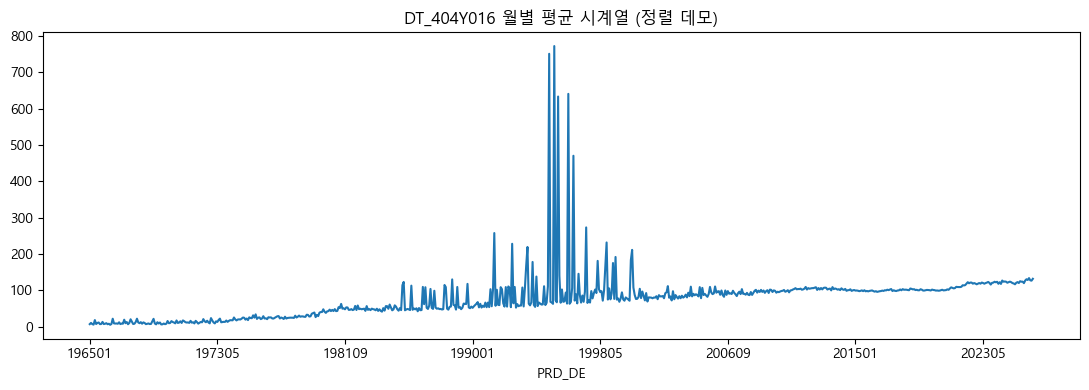

In [30]:
# 시계열 정렬 데모: 월 단위 값을 시점 정렬
demo = rows[(rows["prd_se"] == "M") & rows["dt_num"].notna()]
if len(demo):
    ex_tbl = demo["tbl_id"].value_counts().index[0]
    sub = demo[demo["tbl_id"] == ex_tbl].groupby("prd_de")["dt_num"].mean().sort_index()
    print("예시 표:", ex_tbl, "| 시점", sub.index.min(), "~", sub.index.max(), "| n", len(sub))
    ax = sub.plot(figsize=(11, 4), title=f"{ex_tbl} 월별 평균 시계열 (정렬 데모)")
    ax.set_xlabel("PRD_DE")
    plt.tight_layout(); plt.show()
else:
    print("월 단위 데이터 없음")

## Part 6. 요약 & 산출물

In [31]:
summary = {
    "한국은행 통계표 수": int(len(catalog)),
    "메타 수집": int(len(meta_df)),
    "데이터 수집 성공(전체 포함)": int(collect["ok"].sum()),
    "데이터 수집 실패/부분": int((~collect["ok"]).sum()),
    "전체 수치 행": int(len(rows)),
    "값 결측/비수치 행": int(rows["non_numeric"].sum()),
    "총 API 호출": int(CALLS["count"]),
    "레이트리밋(err40) 발생": int(CALLS["err40"]),
}
for k, v in summary.items():
    print(f"{k}: {v}")

한국은행 통계표 수: 349
메타 수집: 349
데이터 수집 성공(전체 포함): 349
데이터 수집 실패/부분: 0
전체 수치 행: 1500000
값 결측/비수치 행: 0
총 API 호출: 3279
레이트리밋(err40) 발생: 0


In [32]:
# 사용자 표현 ↔ 통계표 명칭 매핑 후보 (검색기 씨앗)
key_terms = ["금리", "기준금리", "환율", "국제수지", "국민계정", "가계부채",
             "기업경기", "소비자", "통화", "대출", "물가", "성장"]
map_rows = []
for term in key_terms:
    hit = catalog[catalog["tbl_nm"].fillna("").str.contains(term)]
    if len(hit):
        map_rows.append({"사용자표현": term, "후보표수": len(hit),
                         "후보예시": " / ".join(hit["tbl_nm"].head(3).tolist())})
mapping = pd.DataFrame(map_rows)
mapping

,사용자표현,후보표수,후보예시
0,금리,9,예금은행 수신금리(신규취급액 기준) / 예금은행 수신금리(잔액 기준) / 예금은행 ...
1,국제수지,1,국제수지
2,기업경기,14,기업경기조사(실적) / 기업경기조사(전망) / 기업경기조사(매출액가중 실적)
3,소비자,3,"소비자동향조사(전국, 분기, 1995.3/4~2008.2/4) / 소비자동향조사(전..."
4,통화,13,지역별 결제통화(수출) / 국가별 결제통화(수출) / 지역별 결제통화(수입)
5,대출,35,대출행태서베이(대출수요) / 대출행태서베이(대출태도) / 대출행태서베이(신용위험)
6,물가,13,국내공급물가지수 / 생산자물가지수(기본분류) / 생산자물가지수(특수분류)
7,성장,10,"경제활동별 성장기여도(계절조정, 실질, 분기) / 경제활동별 성장기여도(원계열, 실..."


In [33]:
# 최종 산출물 확인
print("생성 파일:")
for d in (CATALOG_DIR, META_DIR, RAW_DIR, QC_DIR):
    files = sorted(d.glob("*"))
    print(f"  {d}/  ({len(files)} files)")
    for f in files[:5]:
        print("     -", f.name)
    if len(files) > 5:
        print("     ...")

생성 파일:
  C:\Users\cheon\orca\projects\StatBridge-EX-1\data\catalog/  (2 files)
     - kosis_hankuk_catalog.csv
     - kosis_hankuk_catalog.json
  C:\Users\cheon\orca\projects\StatBridge-EX-1\data\meta/  (350 files)
     - DT_101Y001.json
     - DT_101Y002.json
     - DT_101Y003.json
     - DT_101Y004.json
     - DT_101Y005.json
     ...
  C:\Users\cheon\orca\projects\StatBridge-EX-1\data\raw/  (349 files)
     - DT_101Y001.json
     - DT_101Y002.json
     - DT_101Y003.json
     - DT_101Y004.json
     - DT_101Y005.json
     ...
  C:\Users\cheon\orca\projects\StatBridge-EX-1\data\qc/  (3 files)
     - collect_failures.csv
     - collection_summary.csv
     - qc_report.csv


### 다음 단계 (이 노트북 범위 밖)
- **02 골든셋**: 위 매핑 후보를 씨앗으로 단일/복수/무응답/애매 질의 골든셋 제작
- **검색기**: 표 제목·분류·항목 임베딩 + 키워드 하이브리드 검색
- **MCP 서버**: 탐색/메타/조회/병합/시각화 툴 구현 (요청 시점에 KOSIS 조회)
- QC에서 드러난 `objL` 차원 수·40k 초과 표는 병합/평가 단계의 입력 제약으로 사용